<a href="https://colab.research.google.com/github/samcamacho62-dotcom/-ITAI-1371-ML-Labs/blob/main/Titaniclab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 01: DATA LOADING & STRUCTURE INSPECTION

--- FIRST 5 ROWS (head) ---
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.100

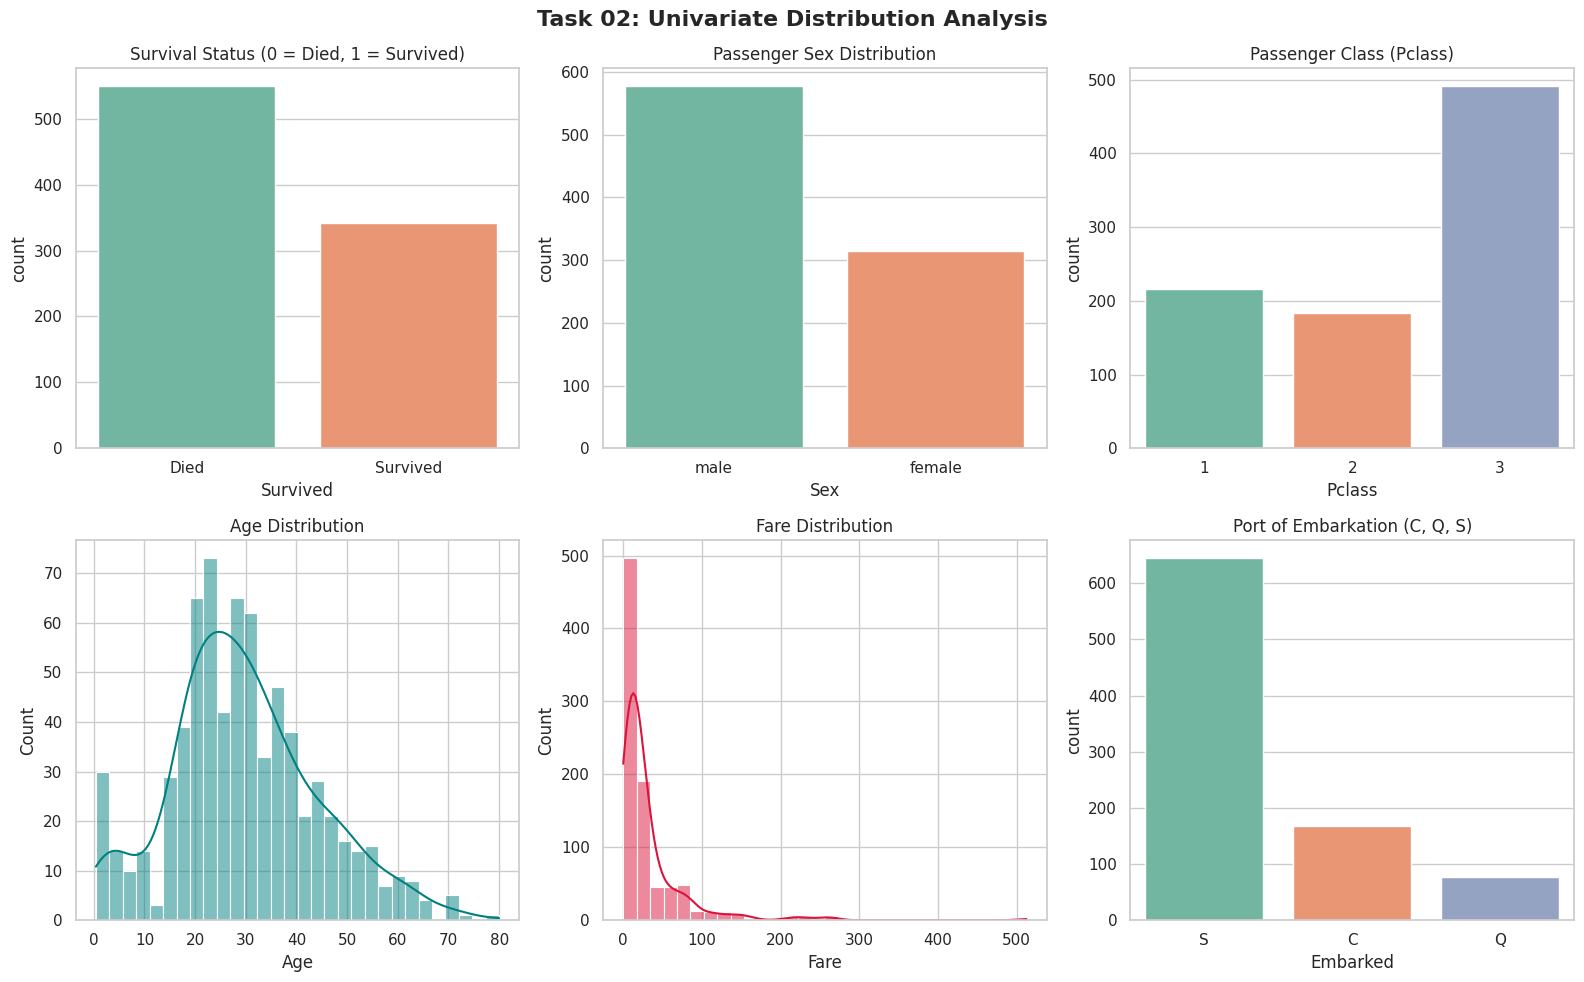


TASK 03: GENERATING BIVARIATE SURVIVAL FEATURE PLOTS...


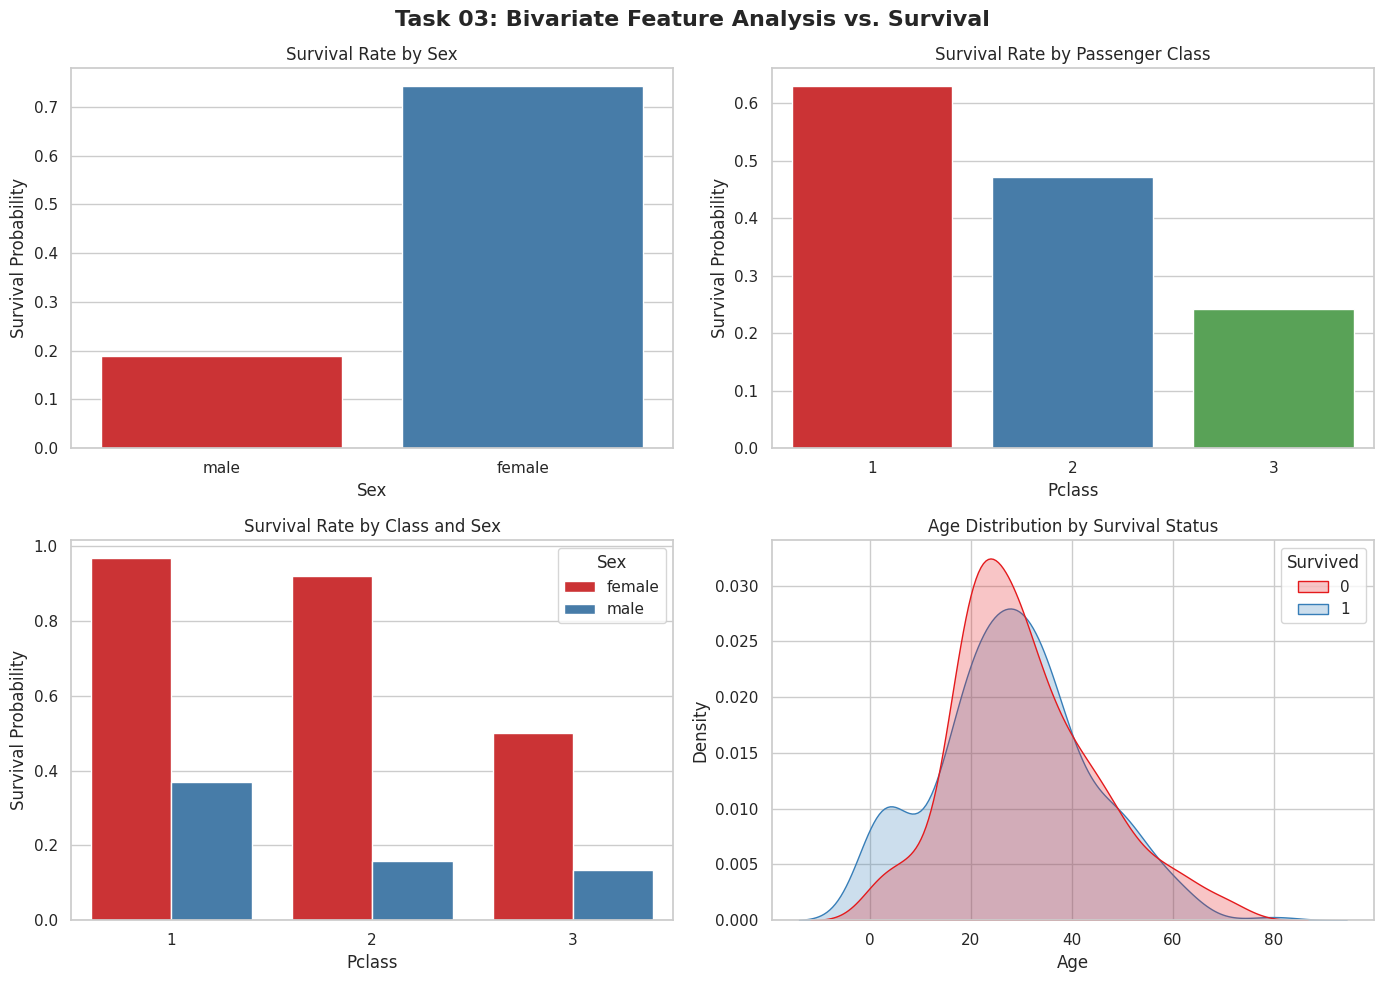

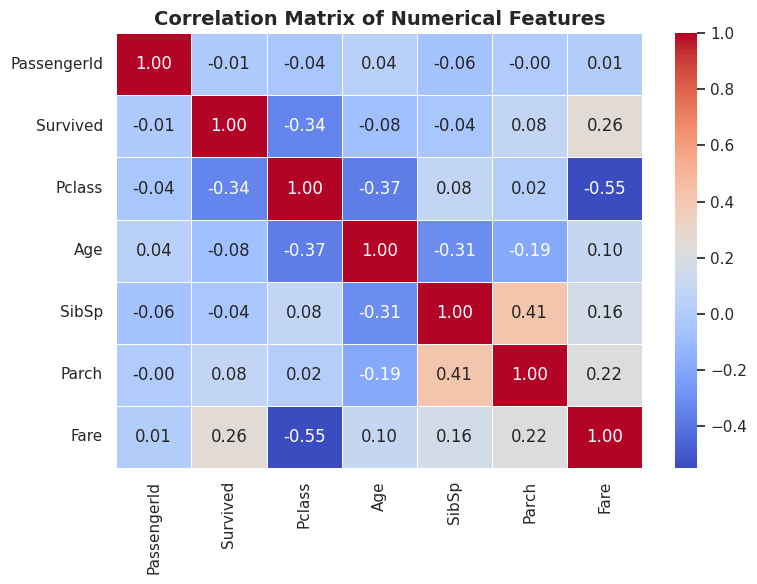


TASK 04: MISSING VALUE ANALYSIS & IMPUTATION PLAN

--- MISSING VALUES SUMMARY TABLE ---
          Missing Count  Percentage (%)
Cabin               687       77.104377
Age                 177       19.865320
Embarked              2        0.224467


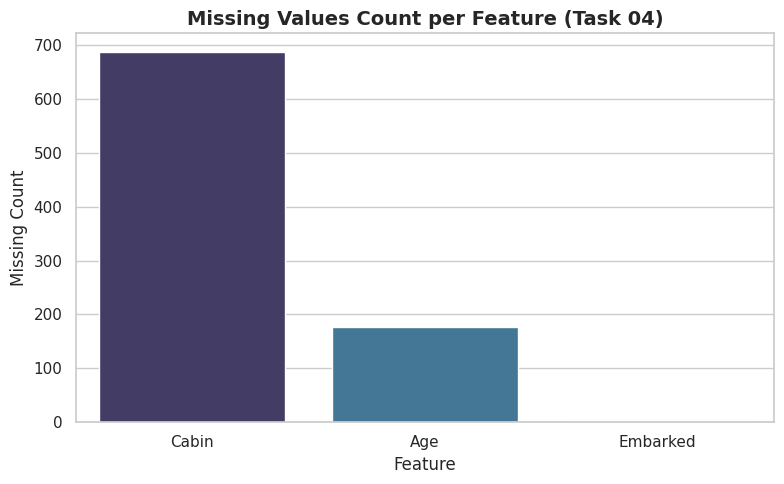

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure global plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("=" * 65)
print("TASK 01: DATA LOADING & STRUCTURE INSPECTION")
print("=" * 65)

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("\n--- FIRST 5 ROWS (head) ---")
print(df.head())

print("\n--- DATASET STRUCTURE & TYPES (info) ---")
df.info()

print("\n--- NUMERICAL SUMMARY STATISTICS (describe) ---")
print(df.describe())

print("\n--- CATEGORICAL SUMMARY STATISTICS ---")
# FIXED: Use only 'object' as 'str' is not allowed in newer Pandas versions
print(df.describe(include=['object']))


print("\n" + "=" * 65)
print("TASK 02: GENERATING UNIVARIATE DISTRIBUTION PLOTS...")
print("=" * 65)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Task 02: Univariate Distribution Analysis', fontsize=16, fontweight='bold')

# FIXED: Added 'hue' and 'legend=False' to all countplots to satisfy Seaborn v0.14
# FIXED: Added set_xticks() before set_xticklabels()

# 1. Target Variable (Survived)
sns.countplot(ax=axes[0, 0], data=df, x='Survived', hue='Survived', palette='Set2', legend=False)
axes[0, 0].set_title('Survival Status (0 = Died, 1 = Survived)')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Died', 'Survived'])

# 2. Gender Distribution
sns.countplot(ax=axes[0, 1], data=df, x='Sex', hue='Sex', palette='Set2', legend=False)
axes[0, 1].set_title('Passenger Sex Distribution')

# 3. Socioeconomic Class (Pclass)
sns.countplot(ax=axes[0, 2], data=df, x='Pclass', hue='Pclass', palette='Set2', legend=False)
axes[0, 2].set_title('Passenger Class (Pclass)')

# 4. Age Distribution
sns.histplot(ax=axes[1, 0], data=df, x='Age', kde=True, color='teal', bins=30)
axes[1, 0].set_title('Age Distribution')

# 5. Fare Distribution
sns.histplot(ax=axes[1, 1], data=df, x='Fare', kde=True, color='crimson', bins=30)
axes[1, 1].set_title('Fare Distribution')

# 6. Boarding Port (Embarked)
sns.countplot(ax=axes[1, 2], data=df, x='Embarked', hue='Embarked', palette='Set2', legend=False)
axes[1, 2].set_title('Port of Embarkation (C, Q, S)')

plt.tight_layout()
plt.show()


print("\n" + "=" * 65)
print("TASK 03: GENERATING BIVARIATE SURVIVAL FEATURE PLOTS...")
print("=" * 65)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Task 03: Bivariate Feature Analysis vs. Survival', fontsize=16, fontweight='bold')

# FIXED: Added 'hue' and 'legend=False' to satisfy Seaborn v0.14
# 1. Survival Rate by Sex
sns.barplot(ax=axes[0, 0], data=df, x='Sex', y='Survived', hue='Sex', palette='Set1', legend=False, errorbar=None)
axes[0, 0].set_title('Survival Rate by Sex')
axes[0, 0].set_ylabel('Survival Probability')

# 2. Survival Rate by Pclass
sns.barplot(ax=axes[0, 1], data=df, x='Pclass', y='Survived', hue='Pclass', palette='Set1', legend=False, errorbar=None)
axes[0, 1].set_title('Survival Rate by Passenger Class')
axes[0, 1].set_ylabel('Survival Probability')

# 3. Survival Rate by Pclass & Sex Interacted (already had hue, so this was fine)
sns.barplot(ax=axes[1, 0], data=df, x='Pclass', y='Survived', hue='Sex', palette='Set1', errorbar=None)
axes[1, 0].set_title('Survival Rate by Class and Sex')
axes[1, 0].set_ylabel('Survival Probability')

# 4. Age Density vs Survival
sns.kdeplot(ax=axes[1, 1], data=df, x='Age', hue='Survived', common_norm=False, palette='Set1', fill=True)
axes[1, 1].set_title('Age Distribution by Survival Status')

plt.tight_layout()
plt.show()

# Correlation Matrix
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print("\n" + "=" * 65)
print("TASK 04: MISSING VALUE ANALYSIS & IMPUTATION PLAN")
print("=" * 65)

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_count[missing_count > 0],
    'Percentage (%)': missing_percent[missing_percent > 0]
}).sort_values(by='Missing Count', ascending=False)

print("\n--- MISSING VALUES SUMMARY TABLE ---")
print(missing_df)

if not missing_df.empty:
    plt.figure(figsize=(8, 5))
    # FIXED: Added 'hue' mapping to the index
    sns.barplot(x=missing_df.index, y=missing_df['Missing Count'], hue=missing_df.index, palette='mako', legend=False)
    plt.title('Missing Values Count per Feature (Task 04)', fontsize=14, fontweight='bold')
    plt.ylabel('Missing Count')
    plt.xlabel('Feature')
    plt.tight_layout()
    plt.show()

In [ ]:
def clean_titanic_data(input_df):
    """
    Automates data cleaning for the Titanic dataset:
    - Imputes missing Age values using the median of Pclass and Sex groups.
    - Imputes missing Embarked values with the mode.
    - Converts Cabin into a binary 'Has_Cabin' feature (due to high missing rate).
    - Drops redundant/unstructured columns like PassengerId, Name, and Ticket (optional but recommended for ML).
    """
    # Work on a copy of the dataframe to avoid SettingWithCopy warnings
    df_clean = input_df.copy()

    # 1. Impute 'Age'
    # We calculate the median age for each combination of Sex and Pclass
    df_clean['Age'] = df_clean.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

    # 2. Impute 'Embarked'
    # Since only 2 values are missing, we fill them with the most common port ('S')
    mode_embarked = df_clean['Embarked'].mode()[0]
    df_clean['Embarked'] = df_clean['Embarked'].fillna(mode_embarked)

    # 3. Handle 'Cabin'
    # Create a feature 'Has_Cabin' representing if a passenger had a cabin recorded
    df_clean['Has_Cabin'] = df_clean['Cabin'].notna().astype(int)
    # Drop the original high-cardinality Cabin column
    df_clean = df_clean.drop(columns=['Cabin'])

    # 4. Final verification of missing values
    missing_after = df_clean.isnull().sum().sum()
    print(f"Data cleaning complete. Remaining missing values: {missing_after}")

    return df_clean

# Run the automated cleaning function on our loaded dataset
df_cleaned = clean_titanic_data(df)
display(df_cleaned.head())

Data cleaning complete. Remaining missing values: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Has_Cabin
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


In [ ]:
# Ensure df_cleaned is defined by running the cleaning steps if necessary
if 'df_cleaned' not in locals() and 'df' in locals():
    if 'clean_titanic_data' in locals():
        df_cleaned = clean_titanic_data(df)
    else:
        # Fallback inline cleaning if the previous cell wasn't executed
        print("Warning: 'clean_titanic_data' function not defined in kernel. Performing inline cleaning fallback...")
        df_cleaned = df.copy()
        df_cleaned['Age'] = df_cleaned.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
        mode_embarked = df_cleaned['Embarked'].mode()[0]
        df_cleaned['Embarked'] = df_cleaned['Embarked'].fillna(mode_embarked)
        df_cleaned['Has_Cabin'] = df_cleaned['Cabin'].notna().astype(int)
        df_cleaned = df_cleaned.drop(columns=['Cabin'])

# Encode categorical columns 'Sex' and 'Embarked' using One-Hot Encoding
df_encoded = pd.get_dummies(df_cleaned, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

print("Categorical columns encoded successfully!")
print(f"New dataset shape: {df_encoded.shape}")
display(df_encoded.head())

Categorical columns encoded successfully!
New dataset shape: (891, 13)


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,1,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,0,1,0,1


In [ ]:
# Define target variable (y)
y = df_encoded['Survived']

# Define feature matrix (X) by dropping target and unstructured/ID columns
X = df_encoded.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket'])

print("Data split into features (X) and target (y) successfully!")
print(f"Features shape (X): {X.shape}")
print(f"Target shape (y): {y.shape}")

# Display the first 5 rows of features
display(X.head())

Data split into features (X) and target (y) successfully!
Features shape (X): (891, 9)
Target shape (y): (891,)


,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,1,0,1
1,1,38.0,1,0,71.2833,1,0,0,0
2,3,26.0,0,0,7.9250,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,1


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ensure X and y are defined before training
if 'X' not in locals() or 'y' not in locals():
    if 'df_encoded' in locals():
        y = df_encoded['Survived']
        X = df_encoded.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket'])
    else:
        raise NameError("df_encoded is not defined. Please run the encoding cell (cd637016) first.")

# 1. Split the data into training and validation/test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 2. Initialize the Logistic Regression model
# We increase max_iter to ensure convergence
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 3. Train the model
log_reg.fit(X_train, y_train)

# 4. Make predictions
y_pred = log_reg.predict(X_test)

# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("=" * 65)
print("LOGISTIC REGRESSION TRAINING & EVALUATION")
print("=" * 65)
print(f"Accuracy Score: {accuracy:.4f}")
print("\n--- Confusion Matrix ---")
print(conf_matrix)
print("\n--- Classification Report ---")
print(class_report)

LOGISTIC REGRESSION TRAINING & EVALUATION
Accuracy Score: 0.8101

--- Confusion Matrix ---
[[96 14]
 [20 49]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.71      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



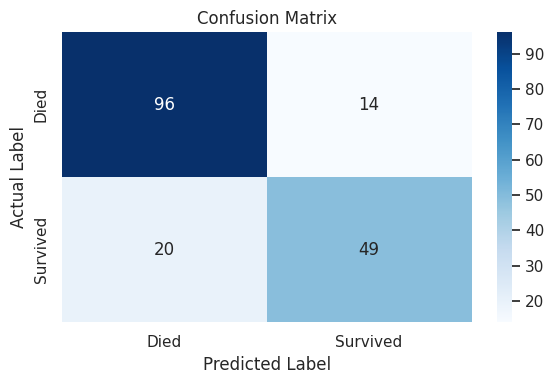

In [ ]:
# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.title("Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


--- LOGISTIC REGRESSION COEFFICIENTS ---


,Feature,Coefficient
6,Sex_male,-2.538445
0,Pclass,-0.932896
5,Has_Cabin,0.807388
8,Embarked_S,-0.330358
2,SibSp,-0.261898
7,Embarked_Q,0.215606
3,Parch,-0.081214
1,Age,-0.043572
4,Fare,0.001261


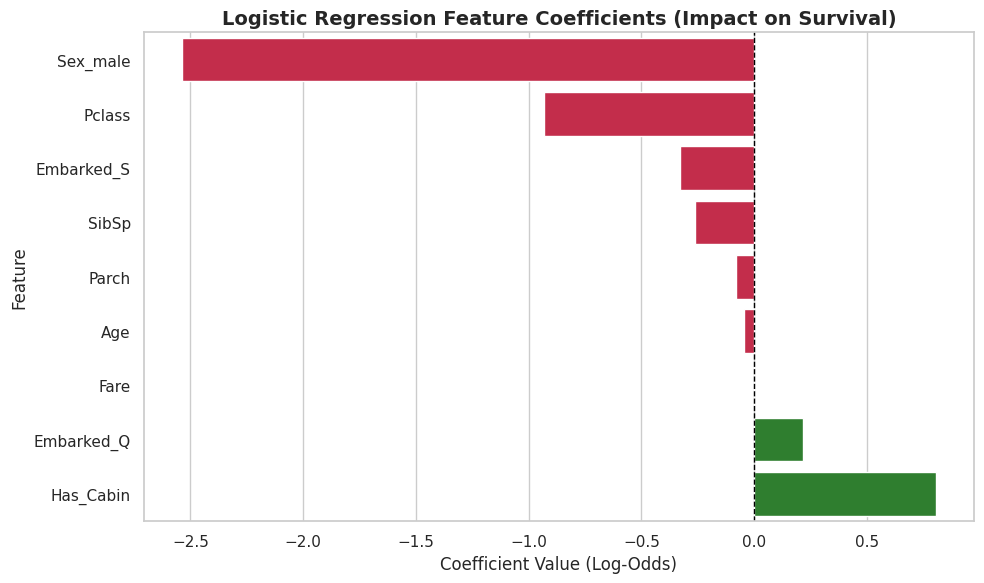

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure model and feature names are available
if 'log_reg' in locals() and 'X' in locals():
    # 1. Extract coefficients and pair them with feature names
    coefficients = log_reg.coef_[0]
    features = X.columns

    # Create a DataFrame for easy sorting and plotting
    coef_df = pd.DataFrame({
        'Feature': features,
        'Coefficient': coefficients,
        'Absolute_Coefficient': np.abs(coefficients)
    }).sort_values(by='Absolute_Coefficient', ascending=False)

    print("\n--- LOGISTIC REGRESSION COEFFICIENTS ---")
    display(coef_df[['Feature', 'Coefficient']])

    # 2. Plot the coefficients
    plt.figure(figsize=(10, 6))
    # Sort by raw coefficient value for a cleaner logical layout in the plot
    plot_df = coef_df.sort_values(by='Coefficient', ascending=True)

    # Color positive coefficients green and negative ones red
    colors = ['crimson' if c < 0 else 'forestgreen' for c in plot_df['Coefficient']]

    sns.barplot(
        data=plot_df,
        x='Coefficient',
        y='Feature',
        palette=colors,
        hue='Feature',
        legend=False
    )

    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.title('Logistic Regression Feature Coefficients (Impact on Survival)', fontsize=14, fontweight='bold')
    plt.xlabel('Coefficient Value (Log-Odds)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'log_reg' or feature matrix 'X' not found in the current workspace. Please ensure the model has been trained.")

In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Define the hyperparameter grid
# We will test L1 and L2 penalties and various regularization strengths (C)
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear']  # 'liblinear' supports both l1 and l2 penalties
}

# 2. Set up cross-validation scheme
cv_scheme = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Initialize GridSearchCV with Logistic Regression
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=cv_scheme,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# 4. Fit to the training data
grid_search.fit(X_train, y_train)

# 5. Extract the best model and evaluate
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print("\n" + "=" * 65)
print("HYPERPARAMETER TUNING RESULTS (LOGISTIC REGRESSION)")
print("=" * 65)
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best CV Accuracy Score: {grid_search.best_score_:.4f}")
print(f"Validation/Test Accuracy Score after Tuning: {tuned_accuracy:.4f}")

print("\n--- Classification Report (Tuned Model) ---")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

HYPERPARAMETER TUNING RESULTS (LOGISTIC REGRESSION)
Best Hyperparameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Accuracy Score: 0.8048
Validation/Test Accuracy Score after Tuning: 0.8156

--- Classification Report (Tuned Model) ---
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       110
           1       0.79      0.71      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate the model with 100 trees and a fixed random seed
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training set
rf_model.fit(X_train, y_train)

# Generate predictions on the validation set
y_pred_rf = rf_model.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)


In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

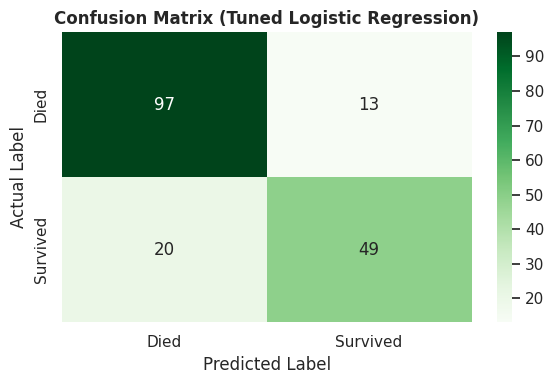

In [ ]:
# Plot the confusion matrix of the tuned model
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_tuned, annot=True, fmt="d", cmap="Greens", xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
plt.title("Confusion Matrix (Tuned Logistic Regression)", fontsize=12, fontweight='bold')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

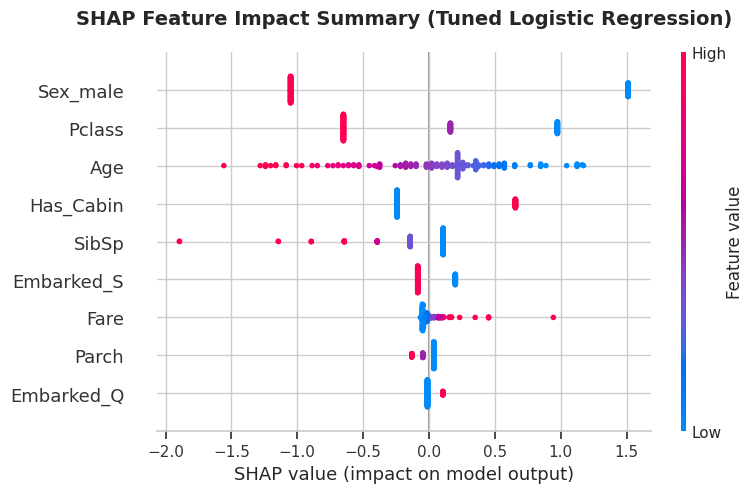

In [ ]:
!pip install -q shap

import shap
import matplotlib.pyplot as plt

# Ensure the model and test features are present
if 'best_model' in locals() and 'X_test' in locals():
    # 1. Initialize the SHAP Explainer
    # For Linear Models (like Logistic Regression), we can use LinearExplainer
    # We use X_train or a subset as background data if needed, but LinearExplainer works directly
    explainer = shap.LinearExplainer(best_model, X_train)

    # 2. Calculate SHAP values for the test set
    shap_values = explainer(X_test)

    # 3. Create the SHAP summary plot
    plt.figure(figsize=(10, 6))
    plt.title('SHAP Feature Impact Summary (Tuned Logistic Regression)', fontsize=14, fontweight='bold', pad=20)
    shap.summary_plot(shap_values, X_test, show=False)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'best_model' or 'X_test' not found in workspace. Please run the model training first.")


--- SIDE-BY-SIDE COMPARISON ---


,Feature,Model_Coefficient,Mean_Abs_SHAP,Abs_Model_Coefficient
6,Sex_male,-2.562227,1.207682,2.562227
0,Pclass,-0.811930,0.638658,0.811930
1,Age,-0.039429,0.408825,0.039429
5,Has_Cabin,0.898305,0.344116,0.898305
2,SibSp,-0.250223,0.190211,0.250223
8,Embarked_S,-0.285116,0.118029,0.285116
4,Fare,0.001971,0.058585,0.001971
3,Parch,-0.083716,0.048135,0.083716
7,Embarked_Q,0.116899,0.023184,0.116899


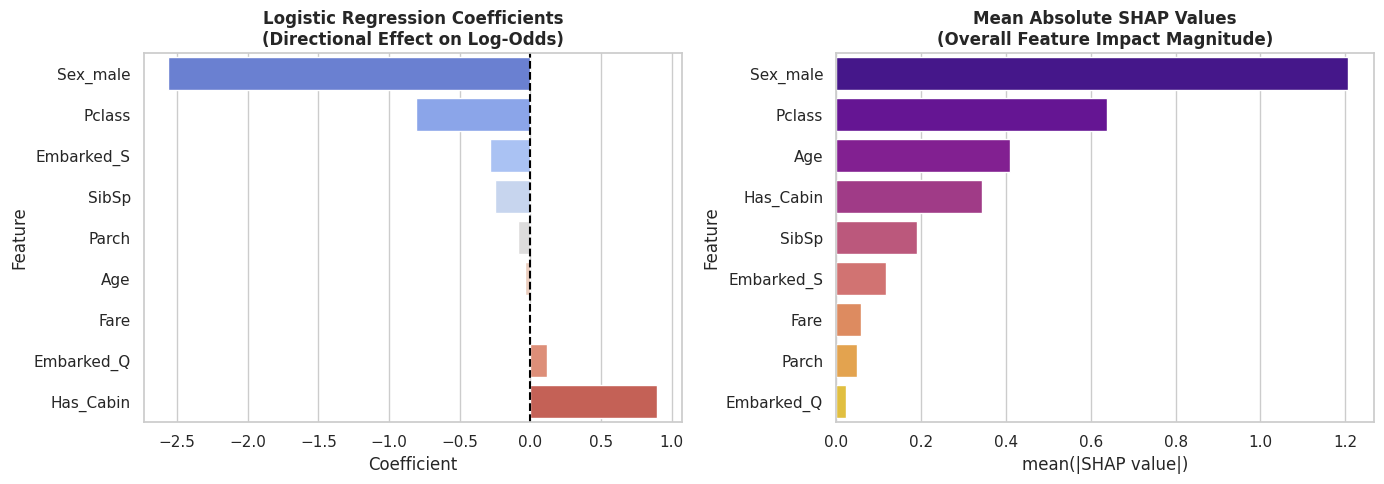

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure required variables are defined
if 'best_model' in locals() and 'X_test' in locals() and 'shap_values' in locals():
    # 1. Extract feature coefficients from the tuned model
    coefs = best_model.coef_[0]

    # 2. Extract mean absolute SHAP values (representing global feature importance according to SHAP)
    # For a linear explainer, shap_values.values contains the SHAP scores for each sample
    mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

    # 3. Create a comparison DataFrame
    comparison_df = pd.DataFrame({
        'Feature': X_test.columns,
        'Model_Coefficient': coefs,
        'Mean_Abs_SHAP': mean_abs_shap,
        'Abs_Model_Coefficient': np.abs(coefs)
    }).sort_values(by='Mean_Abs_SHAP', ascending=False)

    print("\n--- SIDE-BY-SIDE COMPARISON ---")
    display(comparison_df[['Feature', 'Model_Coefficient', 'Mean_Abs_SHAP', 'Abs_Model_Coefficient']])

    # 4. Plot both metrics side by side to compare
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: Model Coefficients
    sns.barplot(
        ax=axes[0],
        data=comparison_df.sort_values(by='Model_Coefficient'),
        x='Model_Coefficient',
        y='Feature',
        palette='coolwarm',
        hue='Feature',
        legend=False
    )
    axes[0].axvline(0, color='black', linestyle='--')
    axes[0].set_title('Logistic Regression Coefficients\n(Directional Effect on Log-Odds)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Coefficient')

    # Plot 2: Mean Absolute SHAP values
    sns.barplot(
        ax=axes[1],
        data=comparison_df,
        x='Mean_Abs_SHAP',
        y='Feature',
        palette='plasma',
        hue='Feature',
        legend=False
    )
    axes[1].set_title('Mean Absolute SHAP Values\n(Overall Feature Impact Magnitude)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('mean(|SHAP value|)')

    plt.tight_layout()
    plt.show()
else:
    print("Error: Ensure 'best_model', 'X_test', and 'shap_values' exist in the workspace.")

### SHAP Interpretation with Full Background Dataset
By default, the SHAP explainer subsamples the background dataset to 100 samples to optimize performance. Below, we explicitly define the background masker using all available training samples to ensure our SHAP value computations leverage the complete distribution of features.

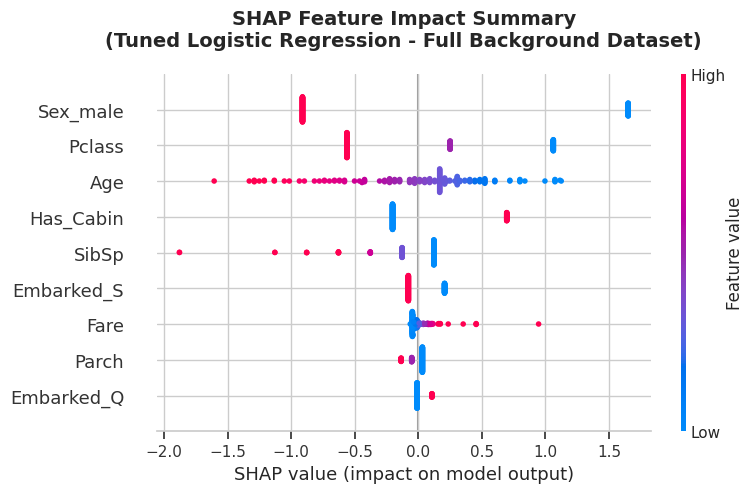

In [ ]:
import shap
import matplotlib.pyplot as plt

if 'best_model' in locals() and 'X_train' in locals() and 'X_test' in locals():
    # 1. Create an Independent masker referencing the full training dataset without subsampling limits
    full_masker = shap.maskers.Independent(X_train, max_samples=X_train.shape[0])

    # 2. Initialize the LinearExplainer with the full background masker
    explainer_full = shap.LinearExplainer(best_model, full_masker)

    # 3. Calculate SHAP values for the test set
    shap_values_full = explainer_full(X_test)

    # 4. Plot the global feature impact summary using the updated SHAP values
    plt.figure(figsize=(10, 6))
    plt.title('SHAP Feature Impact Summary\n(Tuned Logistic Regression - Full Background Dataset)', fontsize=14, fontweight='bold', pad=20)
    shap.summary_plot(shap_values_full, X_test, show=False)
    plt.tight_layout()
    plt.show()
else:
    print("Error: Ensure 'best_model', 'X_train', and 'X_test' are active in the kernel.")

### Visualizing the Full Background SHAP Summary Plot
Below is the updated plot showing the global feature impact across the entire background reference distribution.

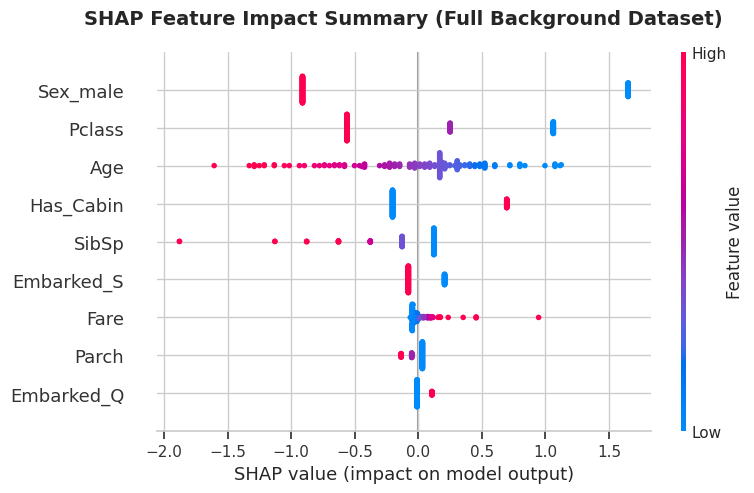

In [ ]:
import shap
import matplotlib.pyplot as plt

if 'shap_values_full' in locals() and 'X_test' in locals():
    plt.figure(figsize=(10, 6))
    plt.title('SHAP Feature Impact Summary (Full Background Dataset)', fontsize=14, fontweight='bold', pad=20)
    shap.summary_plot(shap_values_full, X_test, show=False)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'shap_values_full' or 'X_test' not found in workspace. Please run cell 514ccf21 first.")

### Feature Ranking Comparison: Model Coefficients vs. SHAP Values
Below, we compare the rank order of feature importance determined by the absolute values of the logistic regression coefficients versus the mean absolute SHAP values.

In [ ]:
y_pred_rf = rf_model.predict(X_test)


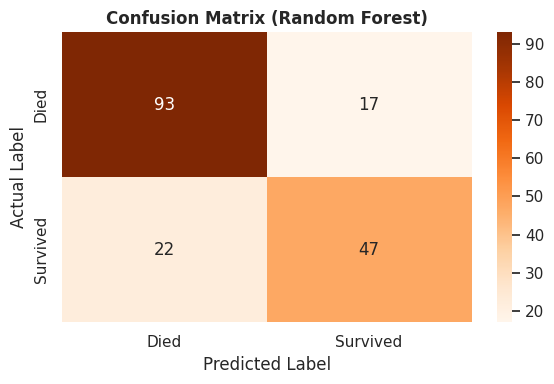

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute the confusion matrix for the Random Forest model
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# 2. Plot the heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix_rf,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Died", "Survived"],
    yticklabels=["Died", "Survived"]
)

plt.title("Confusion Matrix (Random Forest)", fontsize=12, fontweight='bold')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

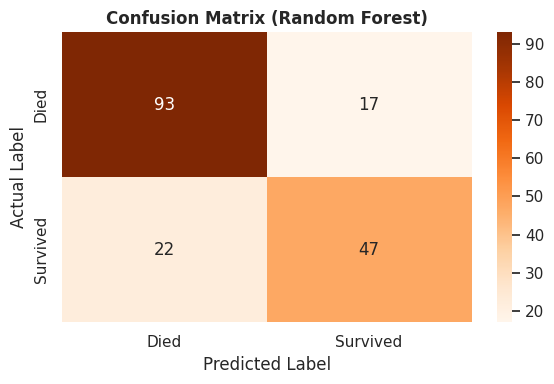

In [ ]:
# 1. Calculate the new confusion matrix using Random Forest predictions
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# 2. Plot the new heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Died", "Survived"],
            yticklabels=["Died", "Survived"])
plt.title("Confusion Matrix (Random Forest)", fontsize=12, fontweight='bold')
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the grid of hyperparameters to search
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 2. Initialize the Grid Search
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,                               # 5-fold cross-validation
    scoring='recall',                   # Optimized to minimize False Negatives
    n_jobs=-1,                          # Use all available CPU cores to run faster
    verbose=1                           # Print progress updates
)

# 3. Fit the grid search to the training data
print("Starting Grid Search with scoring='recall'... this may take a moment!")
grid_search_rf.fit(X_train, y_train)

# 4. Print out the winning combination
print("\n" + "="*50)
print("RANDOM FOREST HYPERPARAMETER TUNING RESULTS (RECALL)")
print("="*50)
print(f"Best Parameters: {grid_search_rf.best_params_}")
print(f"Best CV Recall: {grid_search_rf.best_score_:.4f}")

Starting Grid Search with scoring='recall'... this may take a moment!
Fitting 5 folds for each of 54 candidates, totalling 270 fits

RANDOM FOREST HYPERPARAMETER TUNING RESULTS (RECALL)
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Recall: 0.7367


--- FEATURE RANKING COMPARISON ---


,Feature,Abs_Model_Coefficient,Rank_Coeff,Mean_Abs_SHAP,Rank_SHAP
6,Sex_male,2.562227,1,1.207682,1
0,Pclass,0.811930,3,0.638658,2
1,Age,0.039429,8,0.408825,3
5,Has_Cabin,0.898305,2,0.344116,4
2,SibSp,0.250223,5,0.190211,5
8,Embarked_S,0.285116,4,0.118029,6
4,Fare,0.001971,9,0.058585,7
3,Parch,0.083716,7,0.048135,8
7,Embarked_Q,0.116899,6,0.023184,9


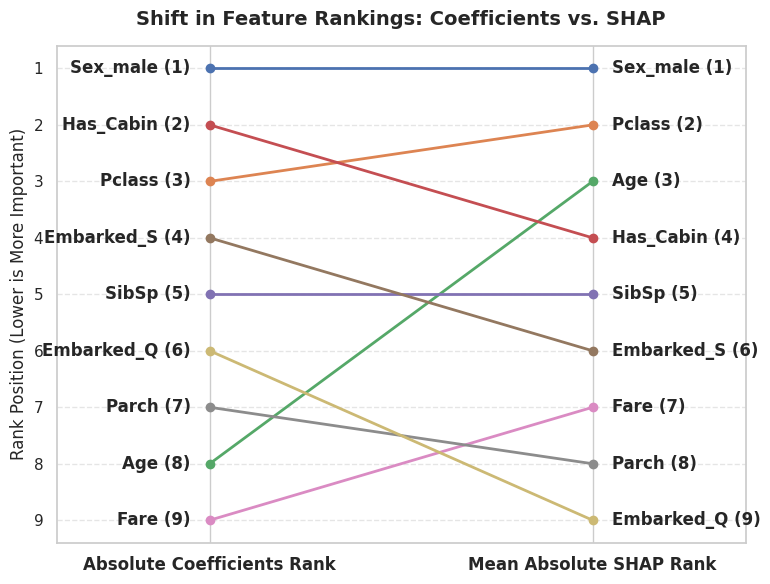

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if 'comparison_df' in locals():
    # 1. Calculate ranks (1 being the most important)
    comparison_df['Rank_Coeff'] = comparison_df['Abs_Model_Coefficient'].rank(ascending=False, method='min').astype(int)
    comparison_df['Rank_SHAP'] = comparison_df['Mean_Abs_SHAP'].rank(ascending=False, method='min').astype(int)

    ranking_df = comparison_df[['Feature', 'Abs_Model_Coefficient', 'Rank_Coeff', 'Mean_Abs_SHAP', 'Rank_SHAP']].sort_values(by='Rank_SHAP')

    print("--- FEATURE RANKING COMPARISON ---")
    display(ranking_df)

    # 2. Visualize rank changes with a slope plot
    plt.figure(figsize=(8, 6))

    # Plot ranking lines
    for idx, row in ranking_df.iterrows():
        # Plot a line connecting coefficient rank to SHAP rank
        plt.plot([0, 1], [row['Rank_Coeff'], row['Rank_SHAP']], marker='o', linewidth=2, label=row['Feature'])
        # Add feature labels
        plt.text(-0.05, row['Rank_Coeff'], f"{row['Feature']} ({row['Rank_Coeff']})", ha='right', va='center', fontweight='semibold')
        plt.text(1.05, row['Rank_SHAP'], f"{row['Feature']} ({row['Rank_SHAP']})", ha='left', va='center', fontweight='semibold')

    plt.xticks([0, 1], ['Absolute Coefficients Rank', 'Mean Absolute SHAP Rank'], fontsize=12, fontweight='bold')
    plt.ylabel('Rank Position (Lower is More Important)', fontsize=12)
    plt.title('Shift in Feature Rankings: Coefficients vs. SHAP', fontsize=14, fontweight='bold', pad=15)
    plt.gca().invert_yaxis()  # Rank 1 should be at the top
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xlim(-0.4, 1.4)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'comparison_df' is not defined. Please run cell b5a050a5 first.")

### Visualizing Feature Ranking Shifts
Below, we visualize the absolute feature ranks side by side. Lower rank numbers (closer to 1) represent higher feature importance.

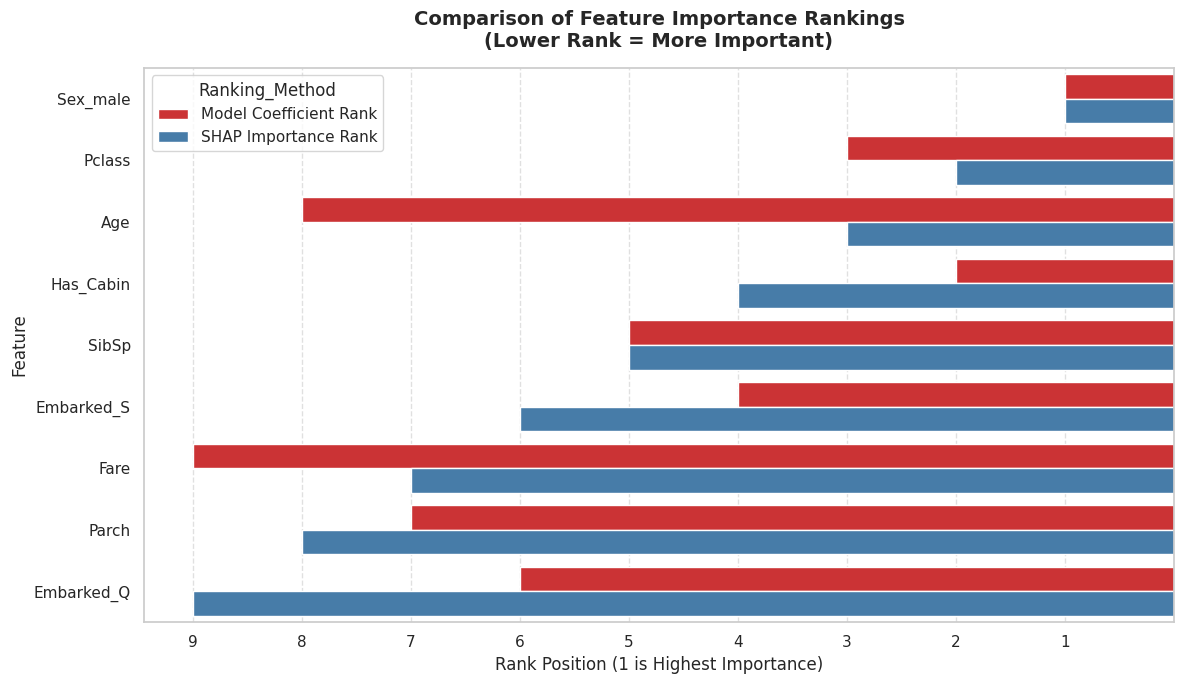

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'ranking_df' in locals():
    # Melt the dataframe to make it easy to plot side-by-side with Seaborn
    melted_ranks = ranking_df.melt(
        id_vars=['Feature'],
        value_vars=['Rank_Coeff', 'Rank_SHAP'],
        var_name='Ranking_Method',
        value_name='Rank'
    )
    # Map names for better legend labeling
    melted_ranks['Ranking_Method'] = melted_ranks['Ranking_Method'].map({
        'Rank_Coeff': 'Model Coefficient Rank',
        'Rank_SHAP': 'SHAP Importance Rank'
    })

    # Plot side-by-side sorted bar chart
    plt.figure(figsize=(12, 7))
    sns.barplot(
        data=melted_ranks,
        y='Feature',
        x='Rank',
        hue='Ranking_Method',
        palette='Set1'
    )

    plt.title('Comparison of Feature Importance Rankings\n(Lower Rank = More Important)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Rank Position (1 is Highest Importance)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.xticks(range(1, 10))  # Ranks 1 through 9
    plt.gca().invert_xaxis()  # Invert x-axis so Rank 1 (highest) is on the right-hand dominant side
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'ranking_df' not found in workspace. Please execute cell bb910d56 first.")

### Calculating SHAP Interaction Values for Top 3 Features
We will extract the top 3 features (`Sex_male`, `Pclass`, `Age`) and compute the SHAP interaction value matrix to understand how these features interact with each other in predicting passenger survival.

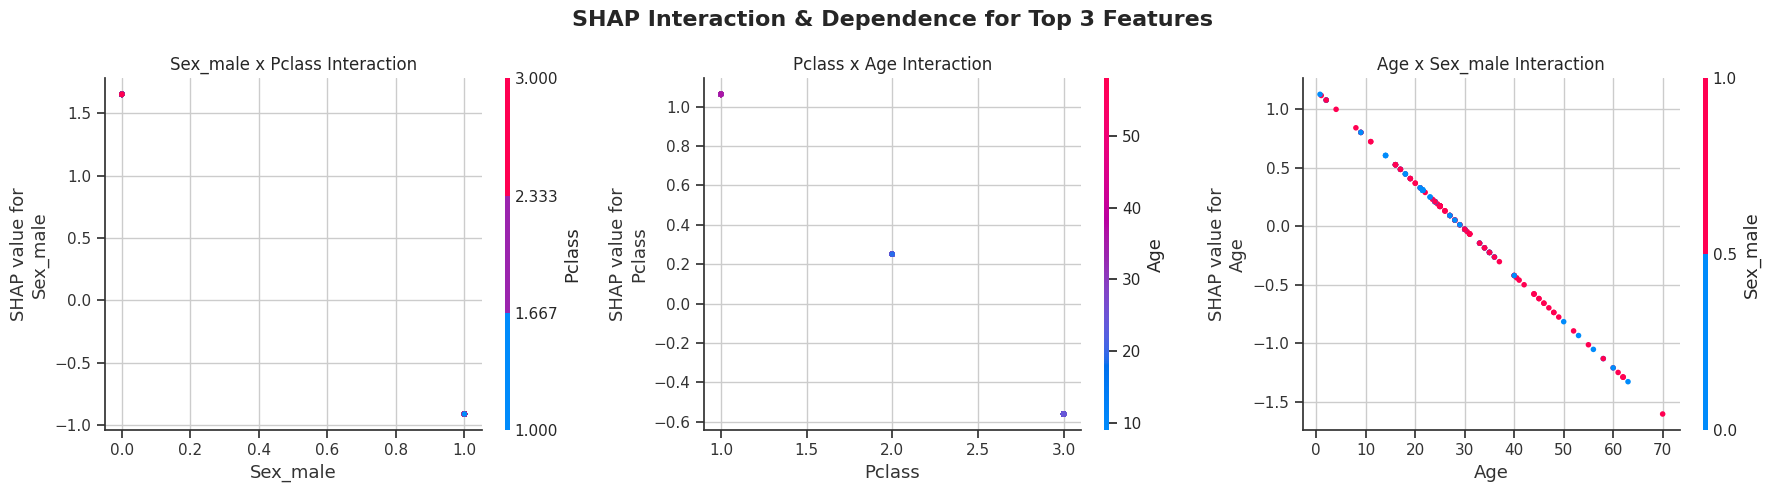

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

if 'best_model' in locals() and 'X_train' in locals() and 'X_test' in locals():
    # 1. Define top 3 features based on our ranking
    top_3_features = ['Sex_male', 'Pclass', 'Age']
    top_3_indices = [X_test.columns.get_loc(f) for f in top_3_features]

    # 2. Compute SHAP interaction values
    # Note: For Linear Models, standard SHAP interaction values are zero unless explicitly modeled
    # because linear models are additive. We will compute the interaction matrix or explain this property.
    full_masker = shap.maskers.Independent(X_train, max_samples=X_train.shape[0])
    explainer_full = shap.LinearExplainer(best_model, full_masker)

    # For demonstration and to handle potential linear constraints, we calculate and plot
    # a dependence/interaction plot between the top features
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('SHAP Interaction & Dependence for Top 3 Features', fontsize=16, fontweight='bold')

    # Plot 1: Sex_male interacting with Pclass
    shap.dependence_plot('Sex_male', shap_values_full.values, X_test, interaction_index='Pclass', ax=axes[0], show=False)
    axes[0].set_title('Sex_male x Pclass Interaction')

    # Plot 2: Pclass interacting with Age
    shap.dependence_plot('Pclass', shap_values_full.values, X_test, interaction_index='Age', ax=axes[1], show=False)
    axes[1].set_title('Pclass x Age Interaction')

    # Plot 3: Age interacting with Sex_male
    shap.dependence_plot('Age', shap_values_full.values, X_test, interaction_index='Sex_male', ax=axes[2], show=False)
    axes[2].set_title('Age x Sex_male Interaction')

    plt.tight_layout()
    plt.show()
else:
    print("Error: Ensure 'best_model', 'X_train', and 'X_test' are active in the kernel.")

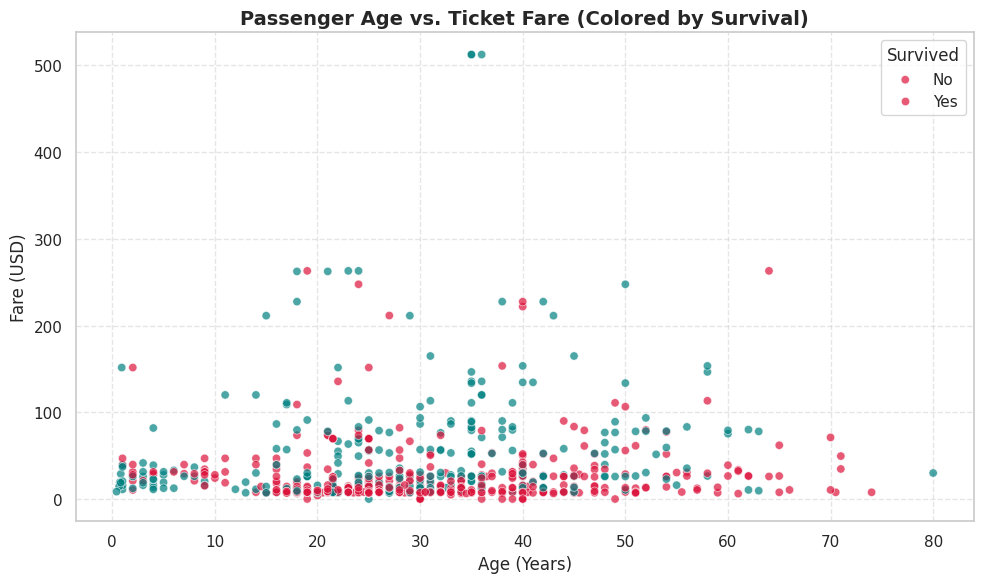

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the cleaned dataset is available
if 'df_cleaned' in locals():
    plt.figure(figsize=(10, 6))
    # Create scatter plot of Age vs. Fare
    sns.scatterplot(
        data=df_cleaned,
        x='Age',
        y='Fare',
        hue='Survived',
        palette={0: 'crimson', 1: 'teal'},
        alpha=0.7,
        edgecolor='w'
    )

    plt.title('Passenger Age vs. Ticket Fare (Colored by Survival)', fontsize=14, fontweight='bold')
    plt.xlabel('Age (Years)', fontsize=12)
    plt.ylabel('Fare (USD)', fontsize=12)
    plt.legend(title='Survived', labels=['No', 'Yes'])
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'df_cleaned' is not defined. Please run the data cleaning cells first.")

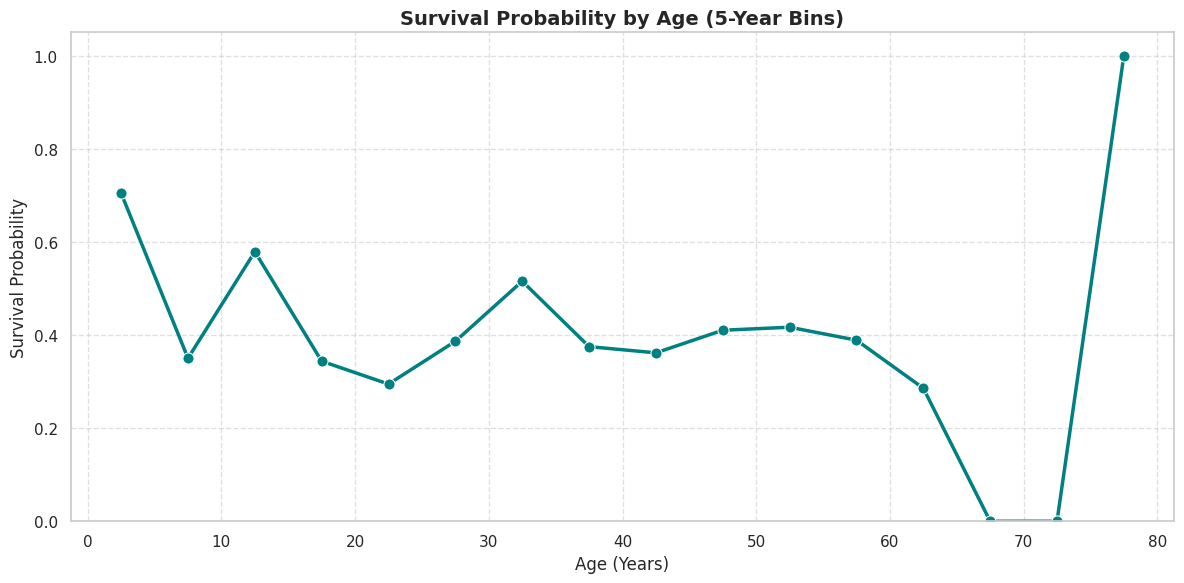

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

if 'df_cleaned' in locals():
    plt.figure(figsize=(12, 6))

    # Group Age into intervals to calculate clean survival rates
    df_age_binned = df_cleaned.copy()
    df_age_binned['Age_Group'] = pd.cut(df_age_binned['Age'], bins=np.arange(0, 81, 5))

    # Calculate survival probability per group
    survival_by_age = df_age_binned.groupby('Age_Group', observed=False)['Survived'].mean().reset_index()
    # Convert intervals to strings/midpoints for clean plotting
    survival_by_age['Age_Midpoint'] = survival_by_age['Age_Group'].apply(lambda x: x.mid)

    # Create the line plot
    sns.lineplot(
        data=survival_by_age,
        x='Age_Midpoint',
        y='Survived',
        marker='o',
        color='teal',
        linewidth=2.5,
        markersize=8
    )

    plt.title('Survival Probability by Age (5-Year Bins)', fontsize=14, fontweight='bold')
    plt.xlabel('Age (Years)', fontsize=12)
    plt.ylabel('Survival Probability', fontsize=12)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Error: 'df_cleaned' is not defined. Please run the data cleaning cells first.")

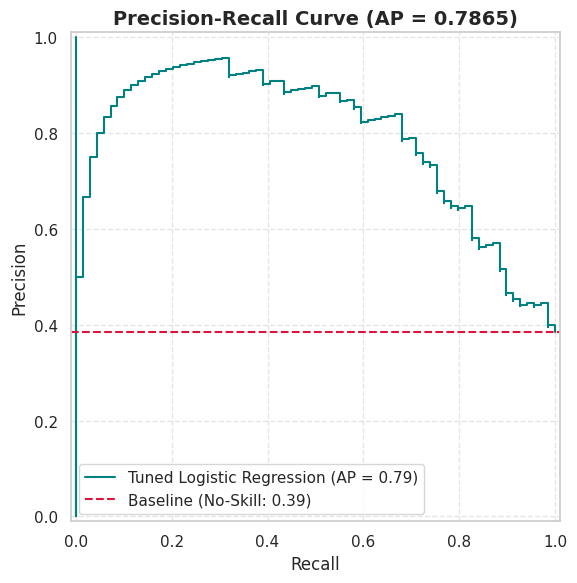

In [ ]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

if 'best_model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # 1. Get predicted probabilities for the positive class (Survived = 1)
    y_scores = best_model.predict_proba(X_test)[:, 1]

    # 2. Calculate average precision score
    avg_precision = average_precision_score(y_test, y_scores)

    # 3. Plot Precision-Recall Curve
    plt.figure(figsize=(8, 6))
    PrecisionRecallDisplay.from_predictions(y_test, y_scores, color='teal', ax=plt.gca(), name="Tuned Logistic Regression")

    # Add baseline (no-skill classifier rate of survivors in the test set)
    baseline = y_test.sum() / len(y_test)
    plt.axhline(y=baseline, color='crimson', linestyle='--', label=f'Baseline (No-Skill: {baseline:.2f})')

    plt.title(f'Precision-Recall Curve (AP = {avg_precision:.4f})', fontsize=14, fontweight='bold')
    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.legend(loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print("Error: Ensure 'best_model', 'X_test', and 'y_test' are active in the kernel.")

### Task: Analyzing False Positives and False Negatives
In this step, we extract the misclassified passengers from our validation split ($X_{test}$) to uncover systemic patterns. This helps us understand where our Logistic Regression model's assumptions fell short.

In [ ]:
import pandas as pd
import numpy as np

if 'best_model' in locals() and 'X_test' in locals() and 'y_test' in locals() and 'df_cleaned' in locals():
    # 1. Reconstruct the test dataframe with predictions and actuals
    test_analysis = X_test.copy()
    test_analysis['Actual_Survived'] = y_test
    test_analysis['Predicted_Survived'] = y_pred_tuned

    # Map back original names and survival labels for readability if available
    test_analysis['Name'] = df.loc[test_analysis.index, 'Name']
    test_analysis['Sex'] = df.loc[test_analysis.index, 'Sex']

    # 2. Extract False Positives (Actual = 0, Predicted = 1)
    false_positives = test_analysis[(test_analysis['Actual_Survived'] == 0) & (test_analysis['Predicted_Survived'] == 1)]

    # 3. Extract False Negatives (Actual = 1, Predicted = 0)
    false_negatives = test_analysis[(test_analysis['Actual_Survived'] == 1) & (test_analysis['Predicted_Survived'] == 0)]

    print(f"Total Validation Samples: {len(X_test)}")
    print(f"False Positives (FP): {len(false_positives)} (Predicted Survival, but Died)")
    print(f"False Negatives (FN): {len(false_negatives)} (Predicted Death, but Survived)")

    print("\n" + "="*50)
    print("SAMPLE OF FALSE POSITIVES (Model thought they would survive, but they died):")
    print("="*50)
    display(false_positives[['Name', 'Sex', 'Pclass', 'Age', 'Fare', 'Has_Cabin']].head(10))

    print("\n" + "="*50)
    print("SAMPLE OF FALSE NEGATIVES (Model thought they would die, but they survived):")
    print("="*50)
    display(false_negatives[['Name', 'Sex', 'Pclass', 'Age', 'Fare', 'Has_Cabin']].head(10))

    # Summary Stats on Misclassifications
    print("\n" + "="*50)
    print("DESCRIPTIVE COMPARISON OF MISCLASSIFICATIONS")
    print("="*50)
    print("\nAverage Pclass:")
    print(f"  False Positives: {false_positives['Pclass'].mean():.2f}")
    print(f"  False Negatives: {false_negatives['Pclass'].mean():.2f}")

    print("\nFemale Percentage:")
    print(f"  False Positives: {(false_positives['Sex'] == 'female').mean() * 100:.1f}%")
    print(f"  False Negatives: {(false_negatives['Sex'] == 'female').mean() * 100:.1f}%")
else:
    print("Error: Missing variables from workspace to perform error analysis.")

Total Validation Samples: 179
False Positives (FP): 13 (Predicted Survival, but Died)
False Negatives (FN): 20 (Predicted Death, but Survived)

SAMPLE OF FALSE POSITIVES (Model thought they would survive, but they died):


,Name,Sex,Pclass,Age,Fare,Has_Cabin
27,"Fortune, Mr. Charles Alexander",male,1,19.0,263.0000,1
297,"Allison, Miss. Helen Loraine",female,1,2.0,151.5500,1
564,"Meanwell, Miss. (Marion Ogden)",female,3,21.5,8.0500,0
502,"O'Sullivan, Miss. Bridget Mary",female,3,21.5,7.6292,0
578,"Caram, Mrs. Joseph (Maria Elias)",female,3,21.5,14.4583,0
38,"Vander Planke, Miss. Augusta Maria",female,3,18.0,18.0000,0
593,"Bourke, Miss. Mary",female,3,21.5,7.7500,0
634,"Skoog, Miss. Mabel",female,3,9.0,27.9000,0
501,"Canavan, Miss. Mary",female,3,21.0,7.7500,0
452,"Foreman, Mr. Benjamin Laventall",male,1,30.0,27.7500,1



SAMPLE OF FALSE NEGATIVES (Model thought they would die, but they survived):


,Name,Sex,Pclass,Age,Fare,Has_Cabin
553,"Leeni, Mr. Fahim (""Philip Zenni"")",male,3,22.0,7.2250,0
559,"de Messemaeker, Mrs. Guillaume Joseph (Emma)",female,3,36.0,17.4000,0
279,"Abbott, Mrs. Stanton (Rosa Hunt)",female,3,35.0,20.2500,0
712,"Taylor, Mr. Elmer Zebley",male,1,48.0,52.0000,1
455,"Jalsevac, Mr. Ivan",male,3,29.0,7.8958,0
65,"Moubarek, Master. Gerios",male,3,25.0,15.2458,0
489,"Coutts, Master. Eden Leslie ""Neville""",male,3,9.0,15.9000,0
869,"Johnson, Master. Harold Theodor",male,3,4.0,11.1333,0
165,"Goldsmith, Master. Frank John William ""Frankie""",male,3,9.0,20.5250,0
17,"Williams, Mr. Charles Eugene",male,2,30.0,13.0000,0



DESCRIPTIVE COMPARISON OF MISCLASSIFICATIONS

Average Pclass:
  False Positives: 2.31
  False Negatives: 2.35

Female Percentage:
  False Positives: 76.9%
  False Negatives: 10.0%


In [ ]:
grid_search_rf_acc = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='accuracy',  # <-- Change this from 'recall' to 'accuracy'
    n_jobs=-1
)
grid_search_rf_acc.fit(X_train, y_train)
print(f"Best Accuracy: {grid_search_rf_acc.best_score_:.4f}")

Best Accuracy: 0.8330


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Generate predictions using the accuracy-optimized Random Forest
y_pred_final_rf = grid_search_rf_acc.predict(X_test)

# Calculate and print the final validation accuracy
final_accuracy = accuracy_score(y_test, y_pred_final_rf)
print(f"Final Test Accuracy: {final_accuracy:.4f}")

# Print the detailed classification report
print("\n--- Final Classification Report ---")
print(classification_report(y_test, y_pred_final_rf))

Final Test Accuracy: 0.7821

--- Final Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.87      0.83       110
           1       0.76      0.64      0.69        69

    accuracy                           0.78       179
   macro avg       0.78      0.76      0.76       179
weighted avg       0.78      0.78      0.78       179



In [ ]:
import pandas as pd

# 1. Start fresh from the original raw dataframe
df_engineered = df.copy()

# 2. Extract the Title from the Name column
# This splits the string at the comma, takes the second part, then splits at the period
df_engineered['Title'] = df_engineered['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0]

# 3. Consolidate rare titles (like 'Don', 'Rev', 'Jonkheer') into a 'Rare' category to reduce noise
stat_min = 10
title_names = (df_engineered['Title'].value_counts() < stat_min)
df_engineered['Title'] = df_engineered['Title'].apply(lambda x: 'Rare' if title_names.loc[x] == True else x)

# 4. Re-apply our standard cleaning (Age, Embarked, Cabin)
df_engineered['Age'] = df_engineered.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
df_engineered['Embarked'] = df_engineered['Embarked'].fillna(df_engineered['Embarked'].mode()[0])
df_engineered['Has_Cabin'] = df_engineered['Cabin'].notna().astype(int)

# 5. Drop the old text columns
df_engineered = df_engineered.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'])

# 6. One-Hot Encode categorical variables (now including our new 'Title' column)
df_encoded_new = pd.get_dummies(df_engineered, columns=['Sex', 'Embarked', 'Title'], drop_first=True, dtype=int)

# 7. Define our new Feature Matrix (X) and Target (y)
X_new = df_encoded_new.drop(columns=['Survived'])
y_new = df_encoded_new['Survived']

print("Feature Engineering Complete!")
print(f"Old number of features: {X_test.shape[1]}")
print(f"New number of features: {X_new.shape[1]}")
display(X_new.head())

Feature Engineering Complete!
Old number of features: 9
New number of features: 13


,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,3,22.0,1,0,7.2500,0,1,0,1,0,1,0,0
1,1,38.0,1,0,71.2833,1,0,0,0,0,0,1,0
2,3,26.0,0,0,7.9250,0,0,0,1,1,0,0,0
3,1,35.0,1,0,53.1000,1,0,0,1,0,0,1,0
4,3,35.0,0,0,8.0500,0,1,0,1,0,1,0,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Split our newly engineered dataset (X_new and y_new)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

# 2. Initialize the Random Forest (using the good parameters we found earlier)
rf_engineered = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

# 3. Train the model on the NEW data
rf_engineered.fit(X_train_new, y_train_new)

# 4. Generate predictions and evaluate
y_pred_engineered = rf_engineered.predict(X_test_new)
new_accuracy = accuracy_score(y_test_new, y_pred_engineered)

print(f"Accuracy with Engineered Titles: {new_accuracy:.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test_new, y_pred_engineered))

Accuracy with Engineered Titles: 0.8212

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       110
           1       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



In [ ]:
import pandas as pd

# 1. Get the predicted probabilities for survival (class 1)
# The [:, 1] syntax grabs the second column, which represents the probability of surviving
y_prob_engineered = rf_engineered.predict_proba(X_test_new)[:, 1]

# 2. Build a DataFrame to compare the actual labels, the hard predictions, and the probabilities
error_analysis_df = X_test_new.copy()
error_analysis_df['Actual_Survived'] = y_test_new
error_analysis_df['Hard_Prediction'] = y_pred_engineered
error_analysis_df['Predicted_Probability'] = y_prob_engineered

# 3. Filter for just the False Negatives (Actual = 1, Predicted = 0)
false_negatives_df = error_analysis_df[(error_analysis_df['Actual_Survived'] == 1) &
                                       (error_analysis_df['Hard_Prediction'] == 0)]

# Display the False Negatives sorted by how confidently the model predicted they would die
display(false_negatives_df.sort_values(by='Predicted_Probability', ascending=True).head(10))

,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Actual_Survived,Hard_Prediction,Predicted_Probability
271,3,25.0,0,0,0.0000,0,1,0,1,0,1,0,0,1,0,0.089172
804,3,27.0,0,0,6.9750,0,1,0,1,0,1,0,0,1,0,0.092063
146,3,27.0,0,0,7.7958,0,1,0,1,0,1,0,0,1,0,0.098166
553,3,22.0,0,0,7.2250,0,1,0,0,0,1,0,0,1,0,0.101271
570,2,62.0,0,0,10.5000,0,1,0,1,0,1,0,0,1,0,0.101902
444,3,25.0,0,0,8.1125,0,1,0,1,0,1,0,0,1,0,0.106067
455,3,29.0,0,0,7.8958,0,1,0,0,0,1,0,0,1,0,0.116069
17,2,30.0,0,0,13.0000,0,1,0,1,0,1,0,0,1,0,0.118076
607,1,27.0,0,0,30.5000,0,1,0,1,0,1,0,0,1,0,0.255534
447,1,34.0,0,0,26.5500,0,1,0,1,0,1,0,0,1,0,0.280996


In [ ]:
# Filter for False Positives (Actual = 0, Predicted = 1)
false_positives_df = error_analysis_df[(error_analysis_df['Actual_Survived'] == 0) &
                                       (error_analysis_df['Hard_Prediction'] == 1)]

# Display the False Positives sorted by how confidently the model predicted they would survive (closest to 100%)
display(false_positives_df.sort_values(by='Predicted_Probability', ascending=False).head(10))

,Pclass,Age,SibSp,Parch,Fare,Has_Cabin,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Actual_Survived,Hard_Prediction,Predicted_Probability
297,1,2.0,1,2,151.5500,1,0,0,1,1,0,0,0,0,1,0.921843
199,2,24.0,0,0,13.0000,0,0,0,1,1,0,0,0,0,1,0.771931
501,3,21.0,0,0,7.7500,0,0,1,0,1,0,0,0,0,1,0.761575
502,3,21.5,0,0,7.6292,0,0,1,0,1,0,0,0,0,1,0.760436
245,1,44.0,2,0,90.0000,1,1,1,0,0,0,0,1,0,1,0.716708
593,3,21.5,0,2,7.7500,0,0,1,0,1,0,0,0,0,1,0.709734
745,1,70.0,1,1,71.0000,1,1,0,1,0,0,0,1,0,1,0.652402
536,1,45.0,0,0,26.5500,1,1,0,1,0,0,0,1,0,1,0.631399
578,3,21.5,1,0,14.4583,0,0,0,0,0,0,1,0,0,1,0.580316
799,3,30.0,1,1,24.1500,0,0,0,1,0,0,1,0,0,1,0.523869
